# Imports

In [318]:
%matplotlib inline

# Stanadard and math imports
import os
import pandas as pd
import numpy as np

# Plotting libs
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science libs
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Machine Learning libs
from scipy import stats
import statsmodels.api as sm
import shap

# Sklear imports
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay


# Exercise 1

## Exercises

File: "first data examples"

- What is the mean age of all persons in the data?
- What is the mean age of female persons? What about male persons?
- How many different types of educations are there?
- What are the different types of education and how many persons are the for each type?
- Is there a difference in educational level across sex?
- What is the most common relationship status?
- Is there a correlation between hours per week (worked) and age?
- Is the average hours per week (worked) different across different marital-status groups?
- Is there an income difference across sexes?

## Age and sex differences

In [319]:
adults = pd.read_csv("Data/adult.csv")

male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()

female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

age_difference = [mean_male_age, mean_female_age, mean_male_age - mean_female_age]

age_difference

[np.float64(39.49439509954058),
 np.float64(36.92798913043478),
 np.float64(2.5664059691058014)]

## Amount of educations

In [320]:
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
educations

,education,people_count
0,HS-grad,15784
1,Some-college,10878
2,Bachelors,8025
3,Masters,2657
4,Assoc-voc,2061
5,11th,1812
6,Assoc-acdm,1601
7,10th,1389
8,7th-8th,955
9,Prof-school,834


## Education level between sexes

In [321]:
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

[mean_male_education_level, mean_female_education_level, mean_male_education_level - mean_female_education_level]

[np.float64(10.094977029096478),
 np.float64(10.044034090909092),
 np.float64(0.05094293818738649)]

## People at different marital statuses

In [322]:
marital_statuses = adults["marital-status"].value_counts().reset_index()
marital_statuses.columns = ["marital-status", "people_count"]
marital_statuses

,marital-status,people_count
0,Married-civ-spouse,22379
1,Never-married,16117
2,Divorced,6633
3,Separated,1530
4,Widowed,1518
5,Married-spouse-absent,628
6,Married-AF-spouse,37


## Hours worked by age

<Axes: title={'center': 'Age vs Hours per Week Worked'}, xlabel='age'>

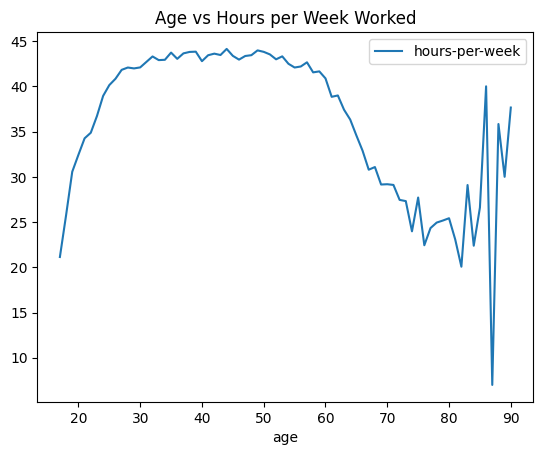

In [323]:
age_vs_work_hours = pd.DataFrame()

age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", title="Age vs Hours per Week Worked")


## Hours worked by marital status 

<Axes: title={'center': 'Marital Status vs Average Hours per Week Worked'}, xlabel='marital-status'>

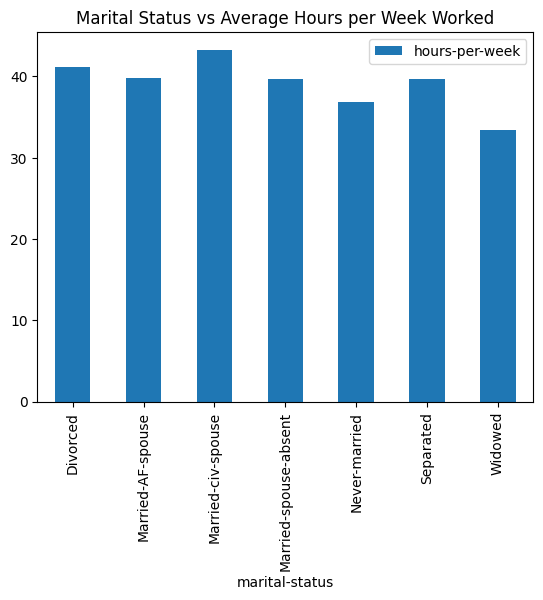

In [324]:
work_hours_by_marital_status = pd.DataFrame()

work_hours_by_marital_status["marital-status"] = adults["marital-status"]
work_hours_by_marital_status["hours-per-week"] = adults["hours-per-week"]

grouped_work_hours_by_marital_status = work_hours_by_marital_status.groupby("marital-status").mean().reset_index()
grouped_work_hours_by_marital_status.plot(x="marital-status", y="hours-per-week", kind="bar", title="Marital Status vs Average Hours per Week Worked")


## Income by sex

<Axes: title={'center': 'Sex vs Number of People Earning >50K'}, xlabel='sex'>

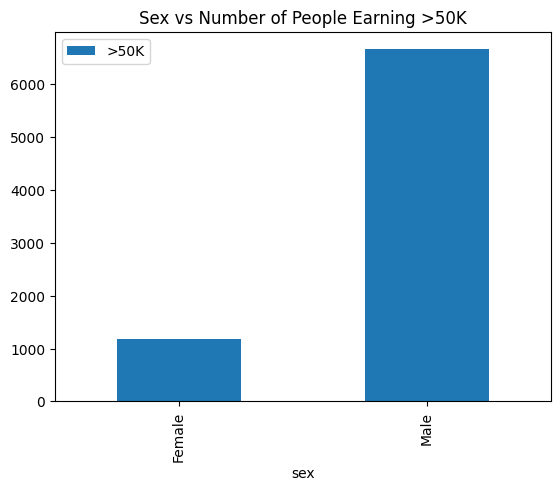

In [325]:
income_by_sex = pd.DataFrame()

income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", title="Sex vs Number of People Earning >50K")


# Exercise 2

## Exercises

File: "Exercises in DT and EDA"

- Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 
- Based on the `Penguins` dataset, answer the following questions:
    - Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
    - Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
    - Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
    - Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
    - Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
    - Visualise how the linear correlation between body mass and flipper length varies between species and sex.
- Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)
- Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)
- Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.


## 2.1

<Axes: title={'center': 'Cinemas in Denmark'}, xlabel='Year'>

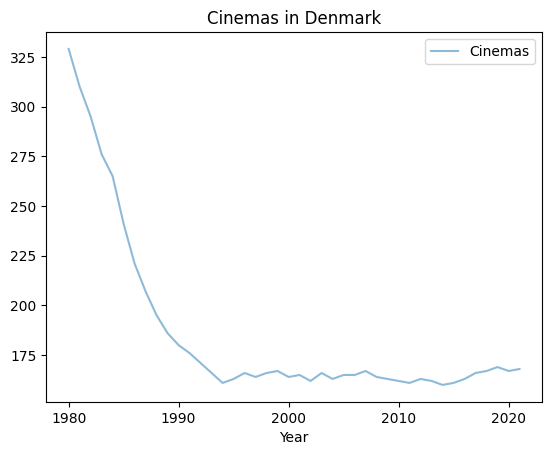

In [326]:
cinemas = pd.read_csv("Data/DK_cinemas.csv", sep=";")

cinemas.plot(x="Year", y="Cinemas", kind="line", title="Cinemas in Denmark", alpha=0.5)

## 2.2

In [327]:
penguins_data = sns.load_dataset("penguins")

penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


<Axes: title={'center': 'Penguin Species Counts'}, xlabel='species'>

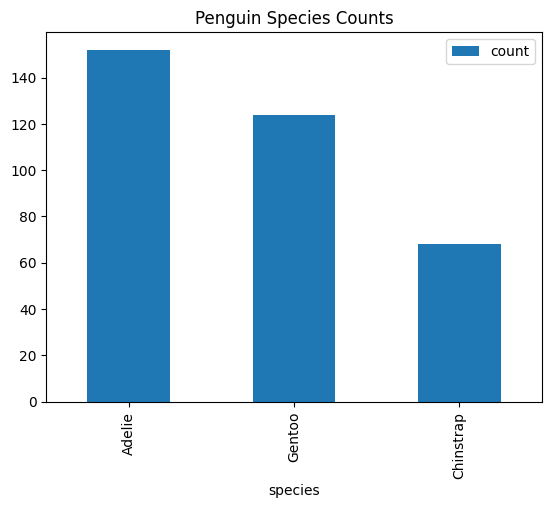

In [328]:
penguin_species = penguins_data["species"].unique()
penguin_species_counts = penguins_data["species"].value_counts().reset_index()

print(penguin_species_counts)
penguin_species_counts.plot(x="species", y="count", kind="bar", title="Penguin Species Counts")

     species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260


<Axes: title={'center': 'Average Body Mass of Penguin Species'}, xlabel='species'>

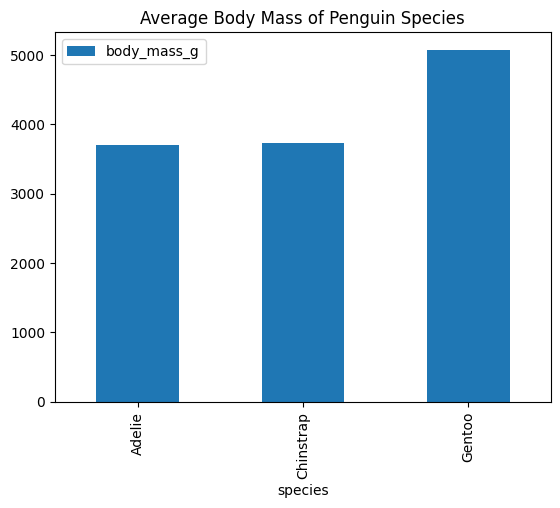

In [329]:
avg_species_bodymass = penguins_data.groupby("species")["body_mass_g"].mean().reset_index()

print(avg_species_bodymass)
avg_species_bodymass.plot(x="species", y="body_mass_g", kind="bar", title="Average Body Mass of Penguin Species")

Averages:
      species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260
Medians:
      species  body_mass_g
0     Adelie       3700.0
1  Chinstrap       3700.0
2     Gentoo       5000.0
1st Quartiles:
      species  body_mass_g
0     Adelie       3350.0
1  Chinstrap       3487.5
2     Gentoo       4700.0
3rd Quartiles:
      species  body_mass_g
0     Adelie       4000.0
1  Chinstrap       3950.0
2     Gentoo       5500.0


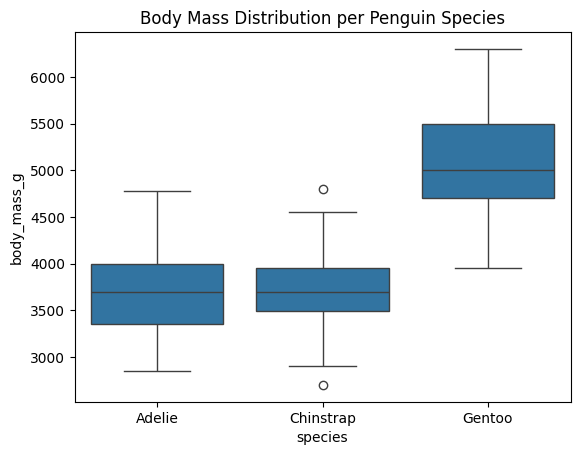

In [330]:
bodymass_distribution_per_species = penguins_data[["species", "body_mass_g"]]

bdps_averages = bodymass_distribution_per_species.groupby("species")["body_mass_g"].mean().reset_index()
bdps_medians = bodymass_distribution_per_species.groupby("species")["body_mass_g"].median().reset_index()
bdps_q1 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.25).reset_index()
bdps_q3 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.75).reset_index()
print("Averages:\n", bdps_averages)
print("Medians:\n", bdps_medians)
print("1st Quartiles:\n", bdps_q1)
print("3rd Quartiles:\n", bdps_q3)

sns.boxplot(x="species", y="body_mass_g", data=bodymass_distribution_per_species)
plt.title("Body Mass Distribution per Penguin Species")
plt.show()

Correlation between Body Mass and Flipper Length:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.839974
flipper_length_mm     0.839974           1.000000


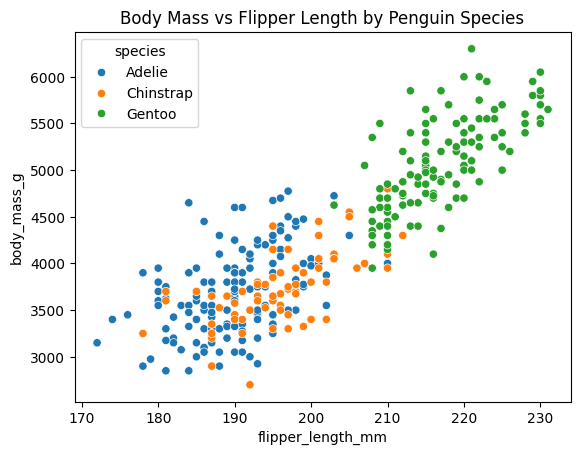

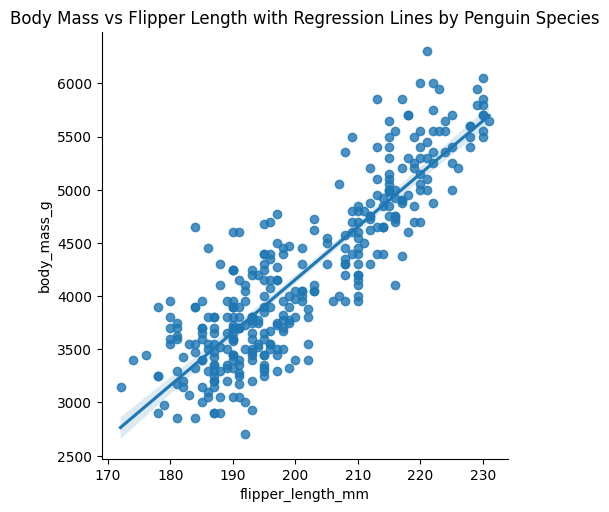

In [331]:
body_mass_to_flipper_length = penguins_data[["body_mass_g", "flipper_length_mm"]]

correlation = body_mass_to_flipper_length.corr('spearman')
print("Correlation between Body Mass and Flipper Length:\n", correlation)

# Fitted graph
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", hue="species", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length by Penguin Species")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length with Regression Lines by Penguin Species")
plt.show()

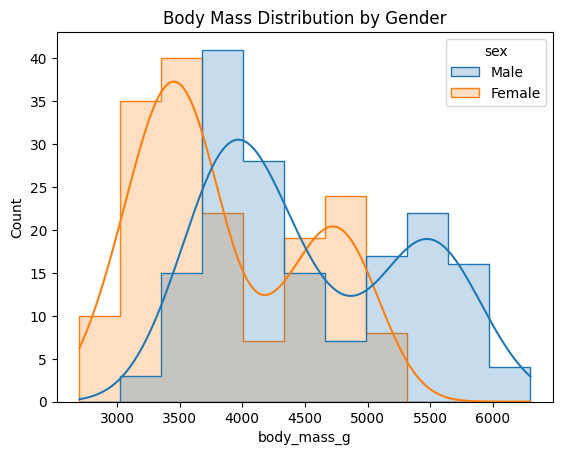

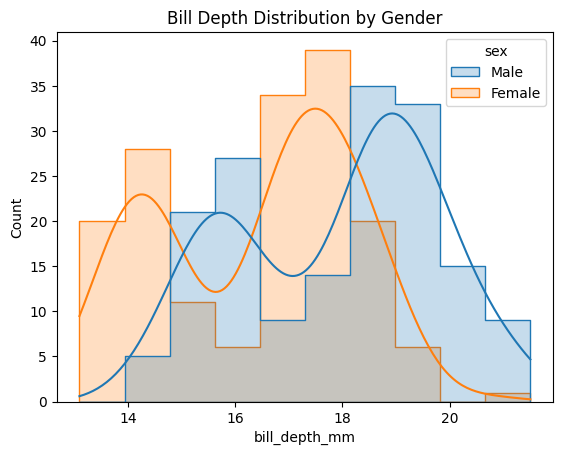

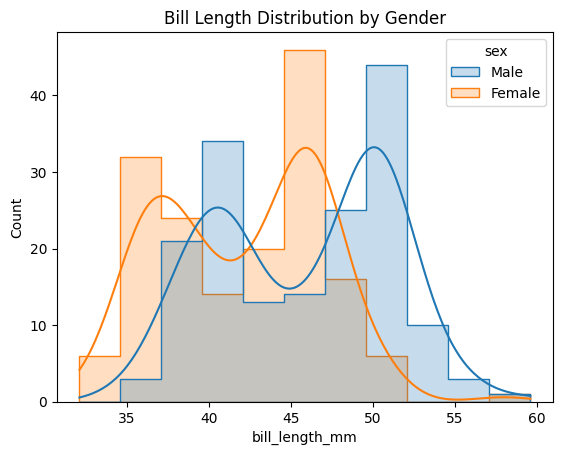

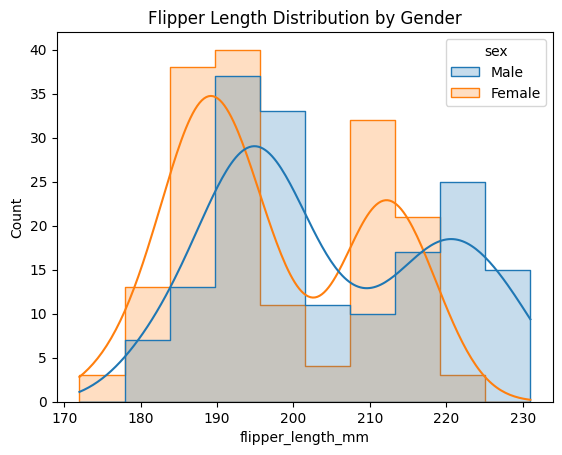

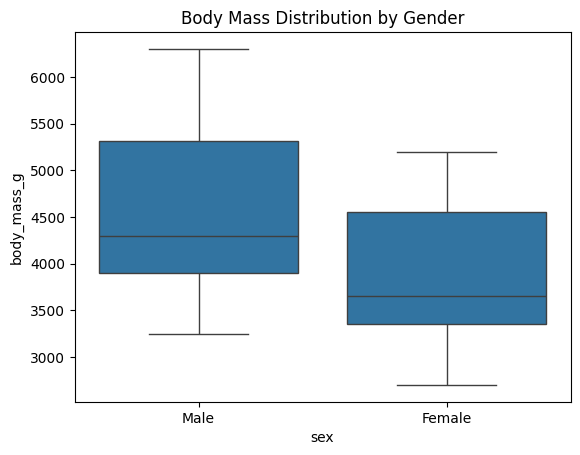

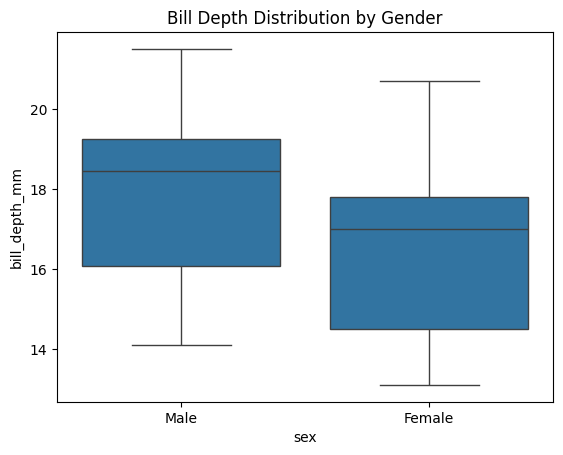

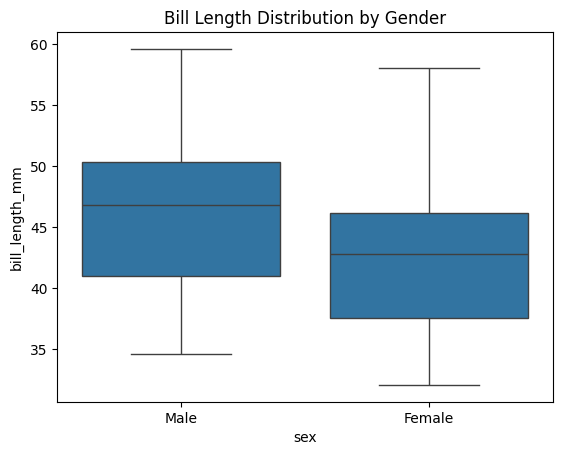

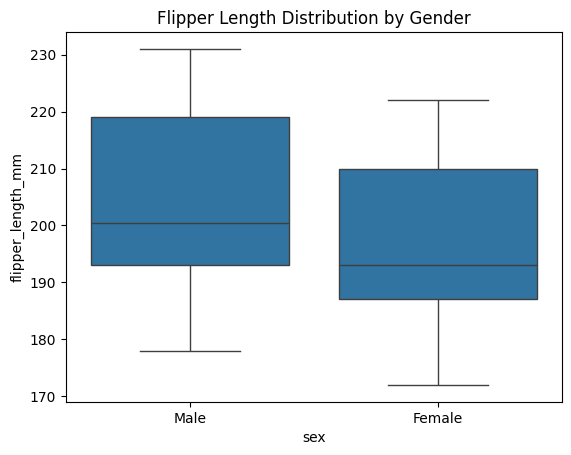

In [332]:
gender_to_bodymass = penguins_data[["sex", "body_mass_g"]]
gender_to_bill_depth = penguins_data[["sex", "bill_depth_mm"]]
gender_to_bill_length = penguins_data[["sex", "bill_length_mm"]]
gender_to_flipper_length = penguins_data[["sex", "flipper_length_mm"]]

# Histograms
sns.histplot(data=gender_to_bodymass, x="body_mass_g", hue="sex", kde=True, element="step")
plt.title("Body Mass Distribution by Gender")
plt.show() 

sns.histplot(data=gender_to_bill_depth, x="bill_depth_mm", hue="sex", kde=True, element="step")
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_bill_length, x="bill_length_mm", hue="sex", kde=True, element="step")
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_flipper_length, x="flipper_length_mm", hue="sex", kde=True, element="step")
plt.title("Flipper Length Distribution by Gender")
plt.show()

# Boxplots
sns.boxplot(x="sex", y="body_mass_g", data=gender_to_bodymass)
plt.title("Body Mass Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_depth_mm", data=gender_to_bill_depth)
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_length_mm", data=gender_to_bill_length)
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="flipper_length_mm", data=gender_to_flipper_length)
plt.title("Flipper Length Distribution by Gender")
plt.show()

Female Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.790429
flipper_length_mm     0.790429           1.000000
Male Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.796562
flipper_length_mm     0.796562           1.000000


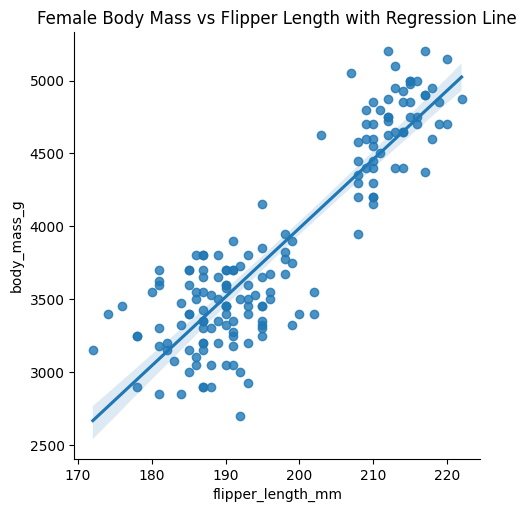

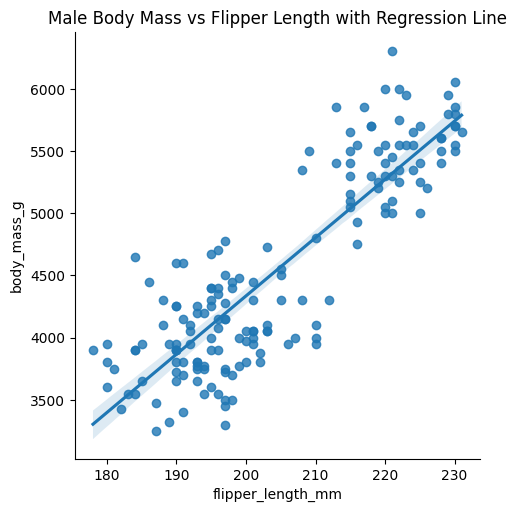

In [333]:
female_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Female"][["body_mass_g", "flipper_length_mm"]]
male_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Male"][["body_mass_g", "flipper_length_mm"]]

female_btfl_correlation = female_bodymass_to_flipper_length.corr('spearman')
male_btfl_correlation = male_bodymass_to_flipper_length.corr('spearman')

print("Female Body Mass to Flipper Length Correlation:\n", female_btfl_correlation)
print("Male Body Mass to Flipper Length Correlation:\n", male_btfl_correlation)

# Fitted graphs
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=female_bodymass_to_flipper_length)
plt.title("Female Body Mass vs Flipper Length with Regression Line")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=male_bodymass_to_flipper_length)
plt.title("Male Body Mass vs Flipper Length with Regression Line")
plt.show()

# Exercise 3

## 3.1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:
1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?
2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?
3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.
4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


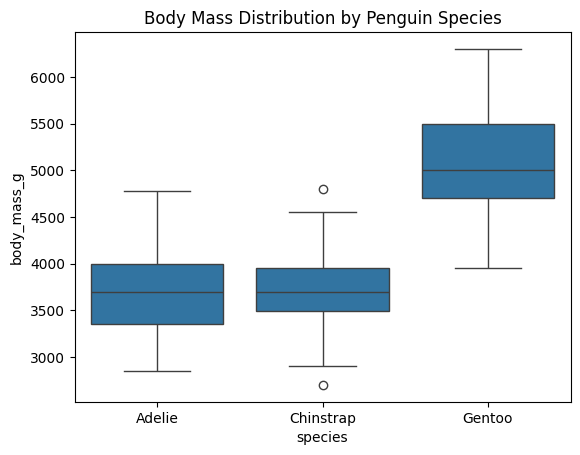

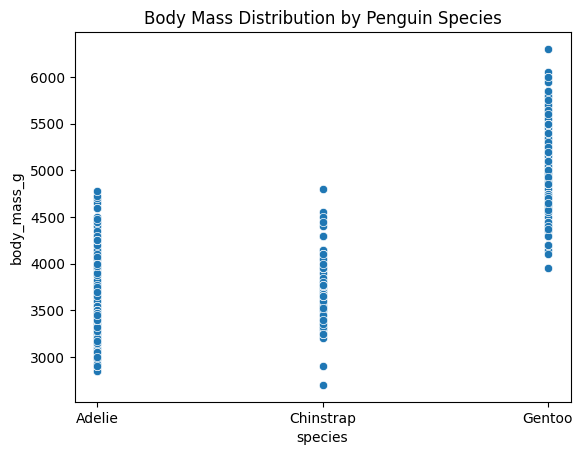

In [334]:
amount_penguins_per_species = penguins_data["species"].value_counts().reset_index()
amount_penguins_per_species.columns = ["species", "count"]
print(amount_penguins_per_species)

sns.boxplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

# Scatterplot of body mass distribution by species
sns.scatterplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

We assume that that both body-masses are normally distributed

In [335]:
adelie_penguins = penguins_data[penguins_data["species"] == "Adelie"]
chinstrap_penguins = penguins_data[penguins_data["species"] == "Chinstrap"]

statistic, p_value = stats.shapiro(adelie_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Adelie Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(chinstrap_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Seeing as the p-value for Adelie penguins is more than 0.05, we fail to reject the null hypothesis,l.

Shapiro-Wilk Test for Adelie Penguins Body Mass:
T-statistic: 0.9807078507062791
P-value: 0.03239702501305105
Shapiro-Wilk Test for Chinstrap Penguins Body Mass:
T-statistic: 0.984493761674102
P-value: 0.5605082387697975


We see that Chinstrap penguins are likely normally distributed, but Adelie are not. Thus we use a Mann-Whitney U test.

H₀: There is no difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie = μ_Chinstrap)

H₁: There is a difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie ≠ μ_Chinstrap)

α = 0.05

In [336]:
u_statistic, p_value_u = stats.mannwhitneyu(adelie_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)


Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:
U-statistic: 4831.0
P-value: 0.4854772721011861


From the result we see that there is no difference in boy mass between the two penguin species.

Comparing Chinstrap and Gentoo we again assume the two sets are normally distributed, knowing that Chinstrap is, we test for Gentoo.

In [337]:
gentoo_penguins = penguins_data[penguins_data["species"] == "Gentoo"]

statistic, p_value = stats.shapiro(gentoo_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Gentoo Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)



Shapiro-Wilk Test for Gentoo Penguins Body Mass:
T-statistic: 0.9859276066609362
P-value: 0.23361648888961845


With a p-value well above 0.05, gentoo penguins are likely normally distributed, so we use a t-test.

H₀: There is no difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo = μ_Chinstrap)

H₁: There is a difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo ≠ μ_Chinstrap)

α = 0.05

In [338]:
statistic, p_value = stats.ttest_ind(gentoo_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("T-Test between Gentoo and Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", round(p_value, 50))


T-Test between Gentoo and Chinstrap Penguins Body Mass:
T-statistic: 19.103227243520955
P-value: 5.2661999999999995e-46


Seeing as the the p-value of our t-test is very well below 0.05, it would strongly suggest that there is a difference in the bodymass of Gentoo and Chinstrap penguins, thus rejecting the null hyphothesis.

## 3.2

Load in the "fb_like_and_share.csv" data and answer the following questions:

1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).
2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).
3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?
4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?

In [339]:
fb_like_and_share = pd.read_csv("Data/fb_like_and_share.csv", sep=";")
fb_like_and_share.head()

,type,likes_count_fb,shares_count_fb
0,video,577,7
1,photo,2802,23
2,video,490,14
3,link,535,16
4,photo,1049,44


In [340]:
fb_photos = fb_like_and_share[fb_like_and_share["type"] == "photo"]
fb_videos = fb_like_and_share[fb_like_and_share["type"] == "video"]

print("Facebook Photos Data:")
print(fb_photos)
print("Facebook Videos Data:")
print(fb_videos)

Facebook Photos Data:
     type  likes_count_fb  shares_count_fb
1   photo            2802               23
4   photo            1049               44
5   photo            1557               85
6   photo             838                1
8   photo             100                1
10  photo            1258               19
11  photo             487                5
12  photo             184               12
14  photo             653               43
19  photo             637                3
26  photo            1544               47
27  photo             320                0
28  photo             329                3
Facebook Videos Data:
     type  likes_count_fb  shares_count_fb
0   video             577                7
2   video             490               14
9   video             112                3
13  video            1051               78
17  video              35                0
20  video             116                1
22  video             175                0
30  video 

We begin by assuming both sets are normally distributed, with an α = 0.05

In [341]:
statistic, p_value = stats.shapiro(fb_photos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Photos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value) 

statistic, p_value = stats.shapiro(fb_videos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Videos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Facebook Photos Like Count:
T-statistic: 0.8774655646725982
P-value: 0.06589939260226885
Shapiro-Wilk Test for Facebook Videos Like Count:
T-statistic: 0.8477493538641958
P-value: 0.07038250110283344


Seeing values above 0.05 for both data sets, we can see that the data is normally distributed with some deviation. This does not reject our null hypothesis, so we can use a t-test to check for differences in like counts between sets with the following hypothesis:

H₀: There is no difference between like counts 
    (μ_Photos = μ_Videos)

H₁: There is a difference between like counts 
    (μ_Photos ≠ μ_Videos)

α = 0.05

In [342]:
statistics, p_value = stats.ttest_ind(fb_photos["likes_count_fb"].dropna(), fb_videos["likes_count_fb"].dropna())

print("T-Test between Facebook Photos and Videos Like Count:")
print("T-statistic:", statistics)
print("P-value:", p_value)


T-Test between Facebook Photos and Videos Like Count:
T-statistic: 2.125454058083514
P-value: 0.04619850270741723


Looking at the p-value of our test, we have a value of 0.046, which is below the significance level, rejecting our null hyphothesis as there's a somewhat strong indication of a difference in like counts between the two sets.

# Exercise 4

## **Exercise**
Complete the following tasks:
1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset) from Kaggle.
2. Visualize the dataset and it's structure using appropriate libraries and plots.
3. Do some basic cleaning to handle missing values
4. Create the following features:
  *   Revenue
  *   DayOfWeek: to analyze sales trends by weekdays.
  *   TotalRevenue for each CustomerID
  *   Most popular product based on Revenue.
  *   Ordersize by summing Quantity for each InvoiceNo
5. Apply a lambda function to:
  * Segment customers into tiers based on TotalRevenue (e.g., "High", "Medium", "Low").
  * Extract key information from Description and add them as columns (e.g., presence of specific keywords like "Gift" or "Discount"). At least one extra column should be added
  * Categorize transactions as "Small", "Medium", or "Large" based on Revenue.
  * **Detect Seasonal Items:** Flag items as "Christmas"-themed if the description contains relevant words.
  * Classify customers as "Loyal", "Occasional", or "One-time" based on the number of purchases.
  *  **Identify Multi-Item Invoices:** Flag invoices with multiple unique items as "Multi-Item Order".
7. Wrap all fo the above into an ETL pipeline.

In [343]:
path = kagglehub.dataset_download("lakshmi25npathi/online-retail-dataset")

print("Path to dataset files:", path)

files = os.listdir(path)
print(files)

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/online-retail-dataset/versions/1
['online_retail_II.xlsx']


In [344]:
file_path = os.path.join(path, files[0])
print(file_path)

online_retail = pd.read_excel(file_path)


/home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/online-retail-dataset/versions/1/online_retail_II.xlsx


In [345]:
online_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [346]:
online_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [347]:
print(online_retail.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [348]:
online_retail.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


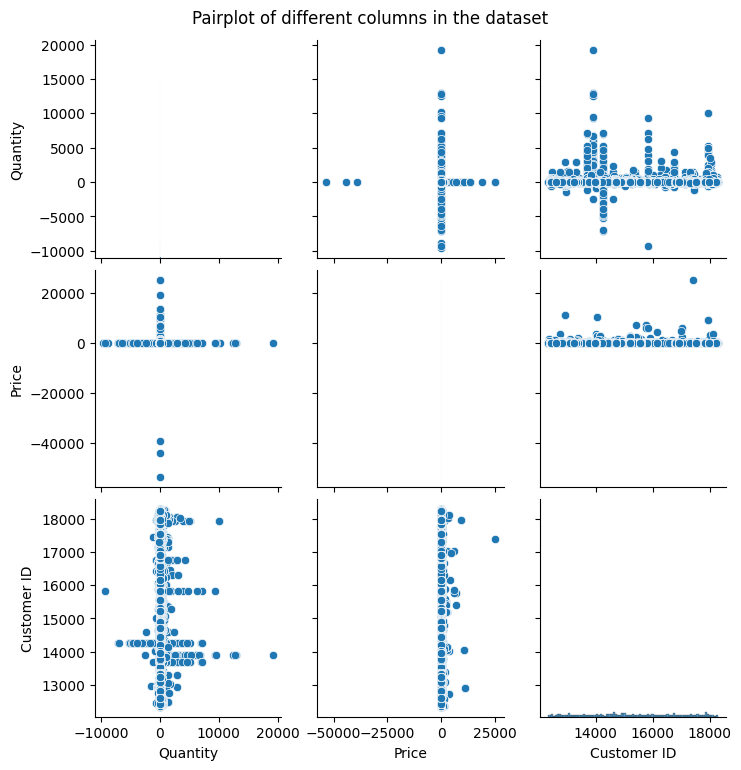

In [349]:
# Plotting different combinations of columns to find interesting relationships in the data

sns.pairplot(online_retail)
plt.suptitle("Pairplot of different columns in the dataset", y=1.02)
plt.show()


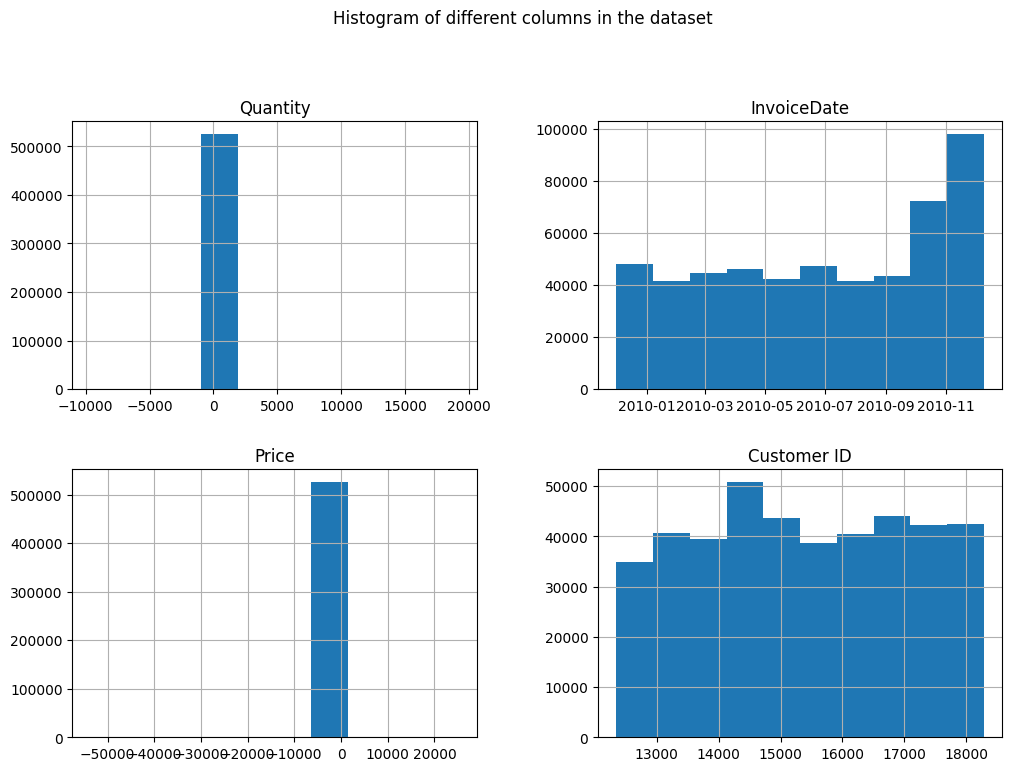

In [350]:
online_retail.hist(figsize=(12, 8))
plt.suptitle("Histogram of different columns in the dataset", y=1.02)
plt.show()

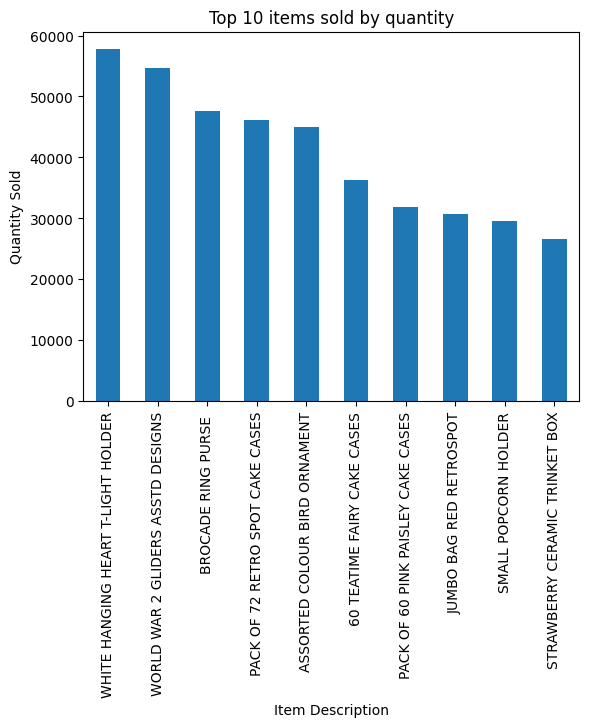

In [351]:
# plotting items sold sorted by quantity sold
online_retail.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 items sold by quantity")
plt.ylabel("Quantity Sold")
plt.xlabel("Item Description")
plt.show()

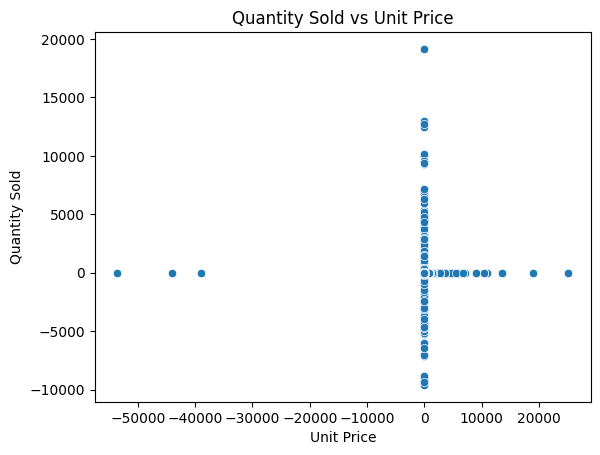

In [352]:
# Scatterplot of quantity sold vs unit price, grouped by item description
sns.scatterplot(x="Price", y="Quantity", data=online_retail)
plt.title("Quantity Sold vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.show()

In [353]:
# Clean the dataset by removing rows with missing values and negative quantities and prices
online_retail_cleaned = online_retail.copy()
online_retail_cleaned = online_retail_cleaned.dropna()
online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Quantity"] > 0]
online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Price"] > 0]
print(online_retail_cleaned.isnull().sum())
online_retail_cleaned.info()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
<class 'pandas.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[us]
 5   Price        407664 non-null  float64       
 6   Customer ID  407664 non-null  float64       
 7   Country      407664 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 28.0+ MB


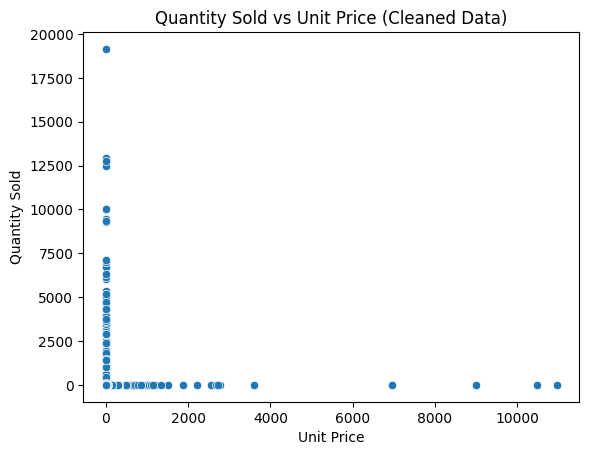

In [354]:
# Plotting again with cleaned dataset, grouped by iprint(online_retail.isnull().sum())tem description
sns.scatterplot(x="Price", y="Quantity", data=online_retail_cleaned)
plt.title("Quantity Sold vs Unit Price (Cleaned Data)")
plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.show()

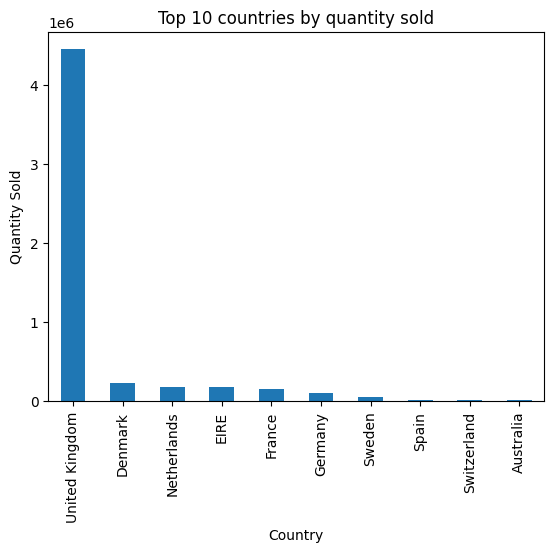

In [355]:
# Most items by country
online_retail_cleaned.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 countries by quantity sold")
plt.ylabel("Quantity Sold")
plt.xlabel("Country")
plt.show()

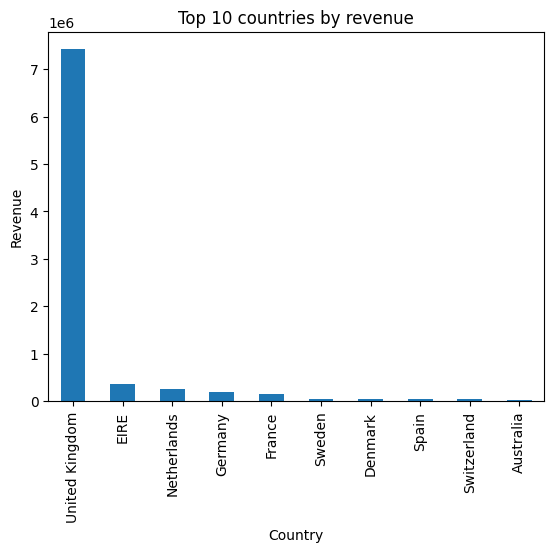

In [356]:
# Most revenue by country
online_retail_cleaned["Revenue"] = online_retail_cleaned["Quantity"] * online_retail_cleaned["Price"]
online_retail_cleaned.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 countries by revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.show()

In [357]:
print(online_retail_cleaned.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom    100.8  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom     30.0  


In [358]:
# Add additional columns for analysis
highest_revenue = online_retail_cleaned["Revenue"].max()
lowest_revenue = online_retail_cleaned["Revenue"].min()

online_retail_cleaned["DayOfWeek"] = online_retail_cleaned["InvoiceDate"].dt.day_name()
online_retail_cleaned["CustomerRevenueTotal"] = online_retail_cleaned.groupby("Customer ID")["Revenue"].transform("sum")
online_retail_cleaned["MostPopularProduct"] = online_retail_cleaned["Revenue"] == highest_revenue
online_retail_cleaned["OrderSize"] = online_retail_cleaned.groupby("Invoice")["Quantity"].transform("sum")
online_retail_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,CustomerRevenueTotal,MostPopularProduct,OrderSize
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday,2017.2,False,166
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,2017.2,False,166
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,2017.2,False,166
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday,2017.2,False,166
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday,2017.2,False,166


In [359]:
# 1. Segment customers into tiers based on CustomerRevenueTotal
highest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].max()
lowest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].min()

online_retail_cleaned["CustomerTier"] = online_retail_cleaned["CustomerRevenueTotal"].apply(
    lambda x: "High" if x > (highest_total_revenue/3)*2+lowest_total_revenue else ("Medium" if x > highest_total_revenue/3+lowest_total_revenue else "Low")
)

# 2. Keyword extraction from Description
online_retail_cleaned["IsGift"] = online_retail_cleaned["Description"].apply(
    lambda x: 1 if "gift" in str(x).lower() else 0
)
online_retail_cleaned["IsDiscount"] = online_retail_cleaned["Description"].apply(
    lambda x: 1 if "discount" in str(x).lower() else 0
)

# 3. Categorize transactions as Small, Medium, or Large based on Revenue
online_retail_cleaned["TransactionSize"] = online_retail_cleaned["Revenue"].apply(
    lambda x: "Large" if x > (highest_revenue/3)*2+lowest_revenue else ("Medium" if x > highest_revenue/3+lowest_revenue else "Small")
)

# 4. Detect Christmas-themed items
christmas_keywords = ["christmas", "xmas", "santa", "reindeer", "holly", "snowman"]
online_retail_cleaned["IsChristmas"] = online_retail_cleaned["Description"].apply(
    lambda x: "Christmas" if any(word in str(x).lower() for word in christmas_keywords) else "Not Christmas"
)

# 5. Classify customer loyalty based on number of unique invoices per customer
purchase_counts = online_retail_cleaned.groupby("Customer ID")["Invoice"].nunique()
online_retail_cleaned["PurchaseCount"] = online_retail_cleaned["Customer ID"].map(purchase_counts)
online_retail_cleaned["CustomerLoyalty"] = online_retail_cleaned["PurchaseCount"].apply(
    lambda x: "Loyal" if x > 10 else ("Occasional" if x > 3 else "One-time")
) # Fixed numbers are good enough for loyalty, it's more vibe based

# 6. Flag invoices with multiple unique items as Multi-Item Order
unique_items_per_invoice = online_retail_cleaned.groupby("Invoice")["StockCode"].nunique()
online_retail_cleaned["UniqueItemCount"] = online_retail_cleaned["Invoice"].map(unique_items_per_invoice)
online_retail_cleaned["MultiItemOrder"] = online_retail_cleaned["UniqueItemCount"].apply(
    lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
)

online_retail_cleaned.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,...,OrderSize,CustomerTier,IsGift,IsDiscount,TransactionSize,IsChristmas,PurchaseCount,CustomerLoyalty,UniqueItemCount,MultiItemOrder
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday,...,166,Low,0,0,Small,Christmas,6,Occasional,8,Multi-Item Order
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order


ETL Pipeline

In [417]:
def etl(dataset_path:str):
    path = kagglehub.dataset_download(dataset_path)
    files = os.listdir(path)
    file_path = os.path.join(path, files[0])

    online_retail = pd.read_excel(file_path)

    online_retail_cleaned = online_retail.copy()
    online_retail_cleaned = online_retail_cleaned.dropna()
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Quantity"] > 0]
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Price"] > 0]

    # Add additional columns for analysis
    online_retail_cleaned["Revenue"] = online_retail_cleaned["Quantity"] * online_retail_cleaned["Price"]
    highest_revenue = online_retail_cleaned["Revenue"].max()
    lowest_revenue = online_retail_cleaned["Revenue"].min()

    online_retail_cleaned["DayOfWeek"] = online_retail_cleaned["InvoiceDate"].dt.day_name()
    online_retail_cleaned["CustomerRevenueTotal"] = online_retail_cleaned.groupby("Customer ID")["Revenue"].transform("sum")
    online_retail_cleaned["MostPopularProduct"] = online_retail_cleaned["Revenue"] == highest_revenue
    online_retail_cleaned["OrderSize"] = online_retail_cleaned.groupby("Invoice")["Quantity"].transform("sum")

    # Lambda functions
    # Segment customers into tiers
    highest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].max()
    lowest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].min()

    online_retail_cleaned["CustomerTier"] = online_retail_cleaned["CustomerRevenueTotal"].apply(
        lambda x: "High" if x > (highest_total_revenue/3)*2+lowest_total_revenue else ("Medium" if x > highest_total_revenue/3+lowest_total_revenue else "Low")
    )

    # Keyword extraction from Description
    online_retail_cleaned["IsGift"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "gift" in str(x).lower() else 0
    )
    online_retail_cleaned["IsDiscount"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "discount" in str(x).lower() else 0
    )

    # Categorize transactions
    online_retail_cleaned["TransactionSize"] = online_retail_cleaned["Revenue"].apply(
        lambda x: "Large" if x > (highest_revenue/3)*2+lowest_revenue else ("Medium" if x > highest_revenue/3+lowest_revenue else "Small")
    )

    # Detect Christmas-themed items
    christmas_keywords = ["christmas", "xmas", "santa", "reindeer", "holly", "snowman"]
    online_retail_cleaned["IsChristmas"] = online_retail_cleaned["Description"].apply(
        lambda x: "Christmas" if any(word in str(x).lower() for word in christmas_keywords) else "Not Christmas"
    )

    # Classify customer loyalty based on number of unique invoices per customer
    purchase_counts = online_retail_cleaned.groupby("Customer ID")["Invoice"].nunique()
    online_retail_cleaned["PurchaseCount"] = online_retail_cleaned["Customer ID"].map(purchase_counts)
    online_retail_cleaned["CustomerLoyalty"] = online_retail_cleaned["PurchaseCount"].apply(
        lambda x: "Loyal" if x > 10 else ("Occasional" if x > 3 else "One-time")
    ) # Fixed numbers are good enough for loyalty, it's more vibe based

    # Include number of unique items per invoice and flag multi-item/single-item orders
    unique_items_per_invoice = online_retail_cleaned.groupby("Invoice")["StockCode"].nunique()
    online_retail_cleaned["UniqueItemCount"] = online_retail_cleaned["Invoice"].map(unique_items_per_invoice)
    online_retail_cleaned["MultiItemOrder"] = online_retail_cleaned["UniqueItemCount"].apply(
        lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
    )

    return online_retail_cleaned


In [418]:
retail_v2 = etl("lakshmi25npathi/online-retail-dataset")
print(retail_v2.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue DayOfWeek  \
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4   Tuesday   
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0   Tuesday   
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0   Tuesday   
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom    100.8   Tuesday   
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom     30.0   Tuesday   

   ...  OrderSize  CustomerTier  IsGift IsDiscount  TransactionSize  \
0  ...        166          

# Exercise 5

## 5.1

Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:
1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).
2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?
3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?
4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).
5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?
6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.
7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.
8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [360]:
data = pd.read_csv("Data/EnergyEfficiency.csv")
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Correlation between Surface Area and Heating Load: -0.6221346966316251


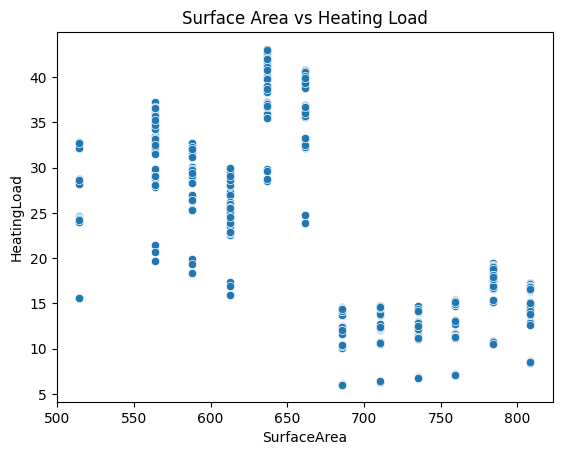

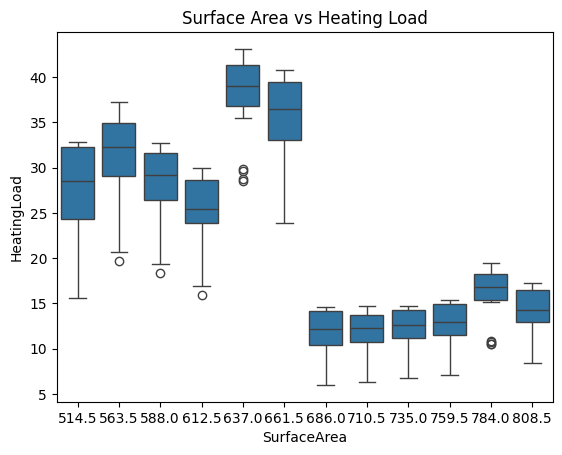

In [361]:
SurfaceArea = data["SurfaceArea"]

HeatingLoad = data["HeatingLoad"]

correlation = SurfaceArea.corr(HeatingLoad, method='spearman')
print("Correlation between Surface Area and Heating Load:", correlation)

sns.scatterplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

sns.boxplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

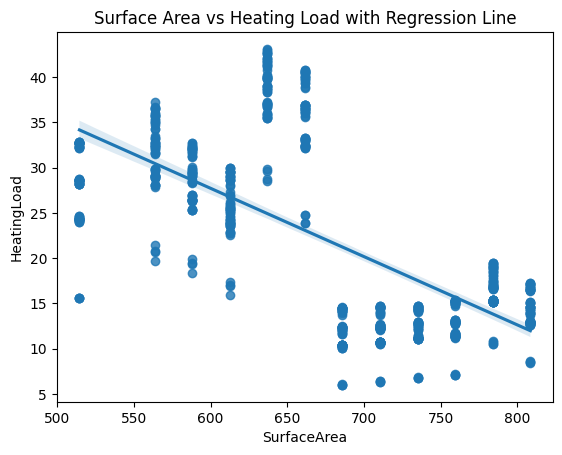

In [362]:
sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load with Regression Line")
plt.show()

In [363]:
# Add constant term (intercept) properly
X = sm.add_constant(SurfaceArea)

# Verify the relationship first
print("Correlation:", SurfaceArea.corr(HeatingLoad))
print("\nFirst few values:")
print("SurfaceArea:", SurfaceArea.head().values)
print("HeatingLoad:", HeatingLoad.head().values)

linreg_statsm = sm.OLS(HeatingLoad, X).fit()

Correlation: -0.658120226777621

First few values:
SurfaceArea: [514.5 514.5 514.5 514.5 563.5]
HeatingLoad: [15.55 15.55 15.55 15.55 20.84]


In [364]:
linreg_statsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        21:17:01   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      0.000      68.801      77.090
SurfaceArea    -0.0754      0.003    -24.192      0.000      -0.082      -0.069
==============================================================================
Omnibus:                       37.973   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.851
Skew:                           0.576   Prob(JB):                     4.95e-10
Kurtosis:                       2.890   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [365]:
(print(linreg_statsm.rsquared))

0.433122232893828


In [366]:
print(linreg_statsm.rsquared_adj)

0.43238218358951186


In [367]:
# MAE

print(np.mean(np.abs(linreg_statsm.resid)))

# MSE

print(np.mean(linreg_statsm.resid**2))

6.002338517195692
57.63983779426345


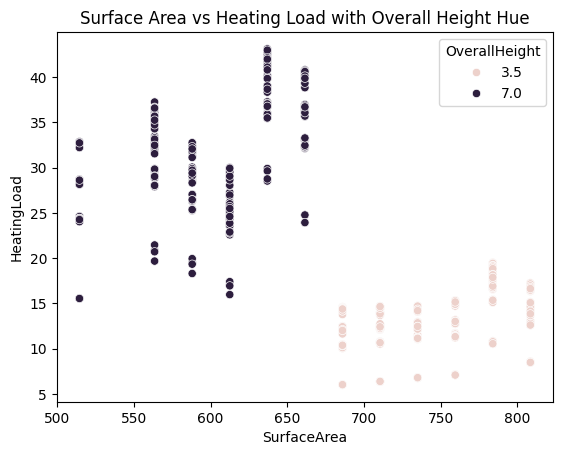

In [368]:
sns.scatterplot(x="SurfaceArea", y="HeatingLoad", hue="OverallHeight", data=data)
plt.title("Surface Area vs Heating Load with Overall Height Hue")
plt.show()

In [369]:
b = linreg_statsm.params

print(b)

const          72.945382
SurfaceArea    -0.075387
dtype: float64


# Exercise 6

## 6.1

1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) from Kaggle. Use the "hour.csv" file.
2. Visualize the structure of the dataset using appropriate libraries and plots.
3. Clean and pre-process the dataset as required and prepare the data for modelling.
4. Create the lag and rolling windows features for the "cnt" column such as: 1 day lag, 1 week lag, 1 month, etc. and last 3 day rolling mean, last 3 hours rolling mean, etc. But it should be based on your dataset and what makes sense for this dataset.
5. Implement linear regression to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.
6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.
7. Experiment with predicting different time periods, such as use all data to predict bike rentals for just the next day (24 hours) or the next entire month and then see how much better or worse the model gets
8. Experiment tuning hyperparameters

In [370]:
# Download dataset
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

# Load the dataset
files = os.listdir(path)
print("Files in dataset:", files)

# Load the hourly data (typically the main file)
hour = pd.read_csv(os.path.join(path, "hour.csv"))

print("First 5 records:")
hour.head()

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Files in dataset: ['Readme.txt', 'hour.csv', 'day.csv']
First 5 records:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [371]:
hour.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [372]:
hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [373]:
hour["dteday"] = pd.to_datetime(hour["dteday"])

In [374]:
hour.duplicated().sum()

np.int64(0)

In [375]:
hour.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


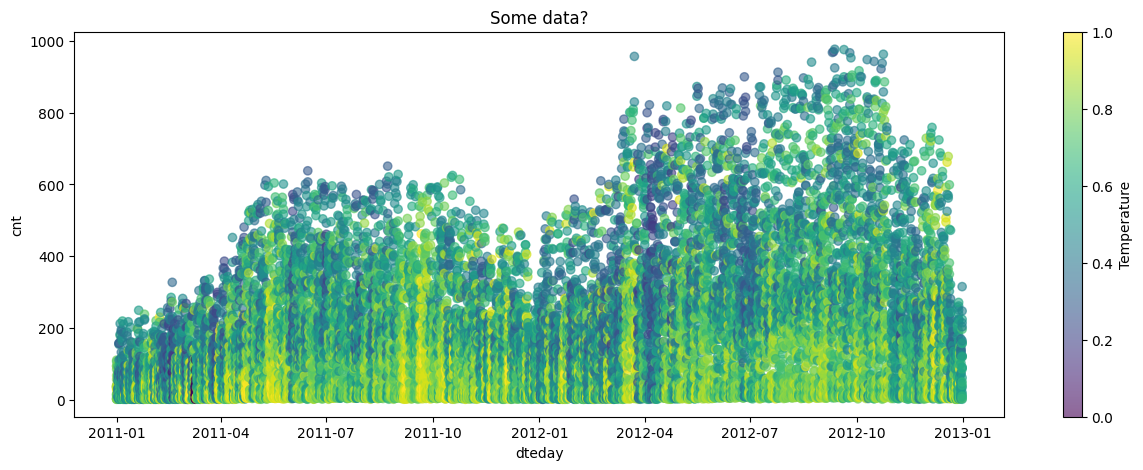

In [376]:
plt.figure(figsize=(15, 5))
plt.scatter(hour["dteday"], hour["cnt"], c=hour["hum"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Temperature")
plt.xlabel("dteday")
plt.ylabel("cnt")
plt.title("Some data?")
plt.show()

In [377]:
hour["datetime_obj"] = pd.to_datetime(hour["dteday"])
hour["Day"] = hour["datetime_obj"].dt.hour
hour["Week"] = hour["datetime_obj"].dt.dayofweek
hour["Month"] = hour["datetime_obj"].dt.month
hour["Year"] = hour["datetime_obj"].dt.year

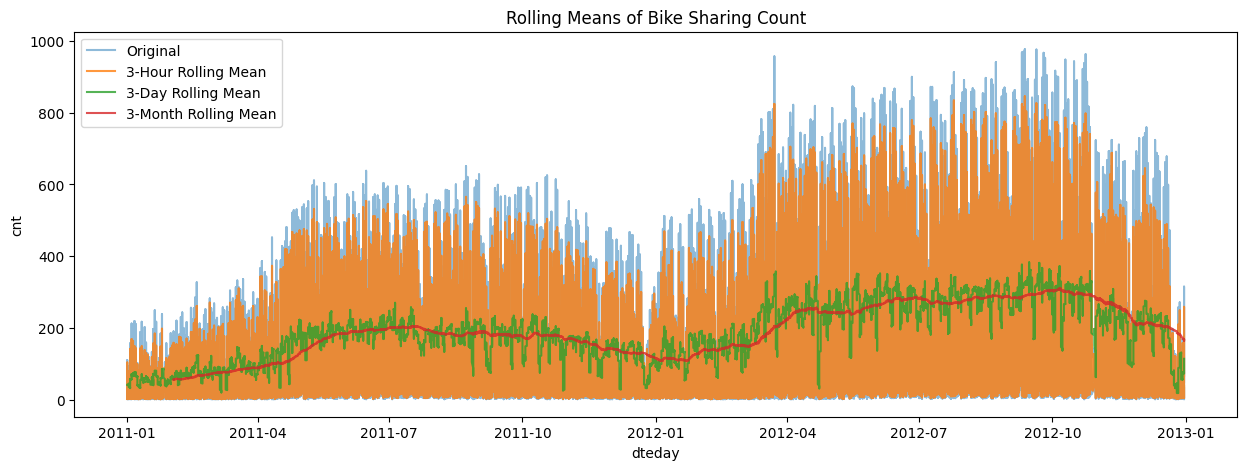

In [378]:
last_3_hour_rolling_mean = hour["cnt"].rolling(window=3).mean()
last_3_day_rolling_mean = hour["cnt"].rolling(window=24).mean()
last_3_month_rolling_mean = hour["cnt"].rolling(window=24*30).mean()

plt.figure(figsize=(15, 5))
plt.plot(hour["dteday"], hour["cnt"], label="Original", alpha=0.5)
plt.plot(hour["dteday"], last_3_hour_rolling_mean, label="3-Hour Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_day_rolling_mean, label="3-Day Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_month_rolling_mean, label="3-Month Rolling Mean", alpha=0.8)
plt.xlabel("dteday")
plt.ylabel("cnt")
plt.title("Rolling Means of Bike Sharing Count")
plt.legend()
plt.show()

# Exercise 7

## 7.1

In this exercise, we will use the titanic dataset to build a KNN classifier for the target variable `Survived`. In this exercise, all the necessary steps are broken down into small individual task you should do. So, do the following tasks:

1. Load in the titanic dataset (on Moodle as "titanic_survival_data.csv"), select the columns "Pclass", "Sex", "Age", and "Fare" for the feature set X and "Survived" for the target variable y.
2. For the columns "Age" and "Fare", replace the missing values with the column's mean.
3. Turn the variables "Pclass" and "Sex" into dummy variables.
4. Do a train-test split of the data with 20% for testing. Use random state 962.
5. Scale the X training dataset, using the standard scaler.
6. Transform the X test dataset with the same scaler fitted in task 5.
7. Train KNN models for multiple K's
8. Train KNN models for K from 2 to 50 and plot the train and test precision and recall.
9. Select the K above 5 with the highest precision and the K above 5 with the highest recall and retrain two models for these values of K
10. For the two models trained in 9, create the confusion matrix and calculate, accuracy precision recall, and f-1 score.

In [379]:
data = pd.read_csv("Data/titanic_survival_data.csv")
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.250,S
1,1,1,female,38.0,1,0,712.833,C
2,1,3,female,26.0,0,0,7.925,S
3,1,1,female,35.0,1,0,53.100,S
4,0,3,male,35.0,0,0,8.050,S


In [380]:
X = data[["Pclass", "Sex", "Age","Fare"]]
Y = data["Survived"]

# Clean Age and Fare columns by filling missing values with the mean
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Get dummies for non numerical columns
X = pd.get_dummies(X, columns=["Sex","Pclass"],)

X.head()


,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,22.0,7.250,False,True,False,False,True
1,38.0,712.833,True,False,True,False,False
2,26.0,7.925,True,False,False,False,True
3,35.0,53.100,True,False,True,False,False
4,35.0,8.050,False,True,False,False,True


In [381]:
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=962)

In [382]:
scalar = sklearn.preprocessing.StandardScaler()
X_train_scaled = pd.DataFrame(scalar.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
109,-0.001709,-0.417652,1.389259,-1.389259,-0.575188,-0.520988,0.926827
622,-0.749967,0.432741,-0.719808,0.719808,-0.575188,-0.520988,0.926827
789,1.259968,-0.066371,-0.719808,0.719808,1.738562,-0.520988,-1.078950
562,-0.131525,-0.485611,-0.719808,0.719808,-0.575188,1.919430,-1.078950
75,-0.363441,-0.522940,-0.719808,0.719808,-0.575188,-0.520988,0.926827


In [383]:
# Train KNN models for k from 2 to 50
k_values = range(2, 51)
train_accuracies = []
test_accuracies = []
train_precisions = []
test_precisions = []
train_recalls = []
test_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    Y_train_pred = knn.predict(X_train_scaled)
    Y_test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    test_accuracies.append(accuracy_score(Y_test, Y_test_pred))
    
    train_precisions.append(precision_score(Y_train, Y_train_pred))
    test_precisions.append(precision_score(Y_test, Y_test_pred))
    
    train_recalls.append(recall_score(Y_train, Y_train_pred))
    test_recalls.append(recall_score(Y_test, Y_test_pred))

print(f"Training complete for k = 2 to 50")

Training complete for k = 2 to 50


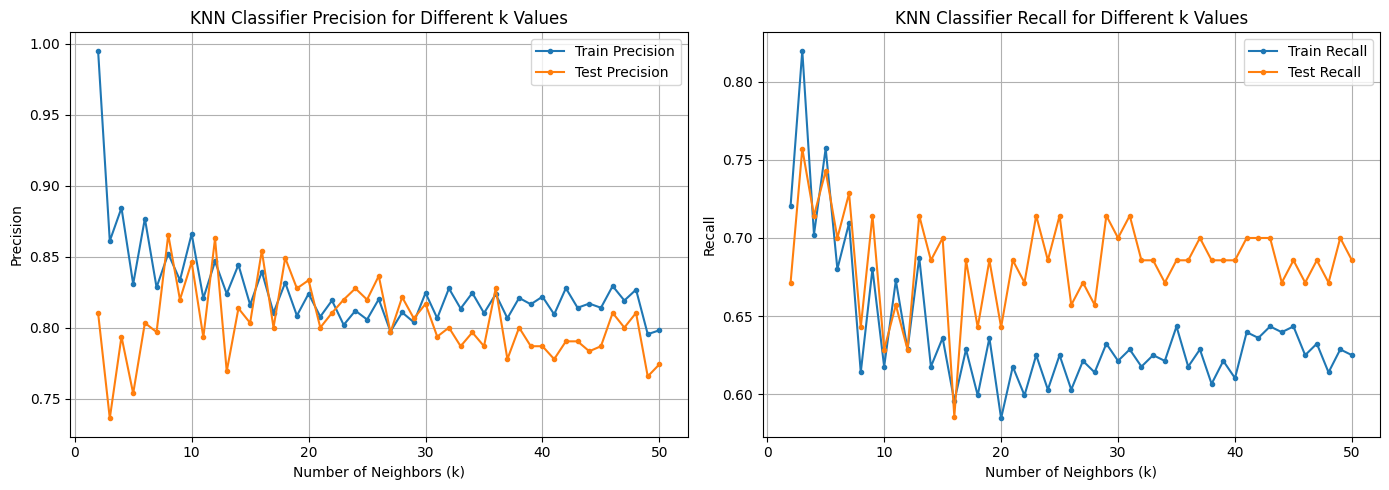

In [384]:
# Plot train and test precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].plot(k_values, train_precisions, marker='o', label='Train Precision', markersize=3)
axes[0].plot(k_values, test_precisions, marker='o', label='Test Precision', markersize=3)
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Precision')
axes[0].set_title('KNN Classifier Precision for Different k Values')
axes[0].legend()
axes[0].grid()

# Recall plot
axes[1].plot(k_values, train_recalls, marker='o', label='Train Recall', markersize=3)
axes[1].plot(k_values, test_recalls, marker='o', label='Test Recall', markersize=3)
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('Recall')
axes[1].set_title('KNN Classifier Recall for Different k Values')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [385]:
# Find best k for precision and recall (k > 5)
best_precision_k = list(k_values)[np.argmax(test_precisions[4:])] + 4  # offset by 4 since we skip k=2,3,4,5
best_recall_k = list(k_values)[np.argmax(test_recalls[4:])] + 4

print(f"Best k for precision (k > 5): {best_precision_k} with precision = {max(test_precisions[4:]):.4f}")
print(f"Best k for recall (k > 5): {best_recall_k} with recall = {max(test_recalls[4:]):.4f}")

Best k for precision (k > 5): 8 with precision = 0.8654
Best k for recall (k > 5): 7 with recall = 0.7286


In [386]:
# Train final models with best k values
knn_best_precision = KNeighborsClassifier(n_neighbors=best_precision_k)
knn_best_precision.fit(X_train_scaled, Y_train)

knn_best_recall = KNeighborsClassifier(n_neighbors=best_recall_k)
knn_best_recall.fit(X_train_scaled, Y_train)

print(f"Models trained for k={best_precision_k} (best precision) and k={best_recall_k} (best recall)")

Models trained for k=8 (best precision) and k=7 (best recall)


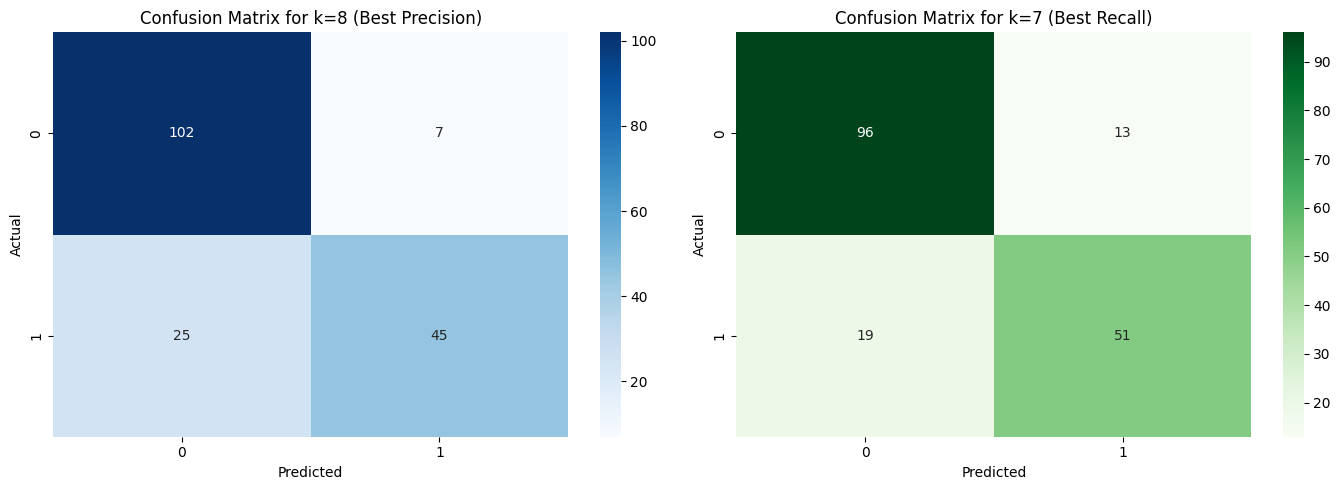

In [387]:
# Condusion matrix

Y_test_pred_precision = knn_best_precision.predict(X_test_scaled)
Y_test_pred_recall = knn_best_recall.predict(X_test_scaled)

cm_precision = confusion_matrix(Y_test, Y_test_pred_precision)
cm_recall = confusion_matrix(Y_test, Y_test_pred_recall)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_precision, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix for k={best_precision_k} (Best Precision)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')  
sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix for k={best_recall_k} (Best Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


# Exercise 8

## 8.1

In this exercise, we will use logistic regression for classification using the diabetes dataset.

Answer the following questions:
1. Load the diabetes dataset (on Moodle as "diabetes.csv")
2. Create a scatter plot of Outcome vs Glucose to visualize the relationship
3. Create a boxplot to compare Glucose levels between people with and without diabetes
4. Select "Glucose" as the feature variable X and "Outcome" as the target variable y
5. Do a train-test split with 25% for testing (use random_state=42)
6. Train a logistic regression model using statsmodels (remember to add constant)
7. Make predictions on the test set
8. Calculate the accuracy of the model
9. Create a visualization showing the logistic regression curve
10. Try adding more features (e.g., BMI, Age) and see if the model improves

# Exercise 9

## 9.1

Simulate sensor data & apply PCA

In this exercise, you will do the following:
1. Simulate sensor data
2. Apply PCA to simulated data
3. Simulate a new point
4. Find out which region the new point belongs to

In [388]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import paho.mqtt.client as mqtt

In [389]:
# Step 1 Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
data = pd.DataFrame(sensors)

print("Sample Data:")
print(data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [390]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Display scaled data
print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

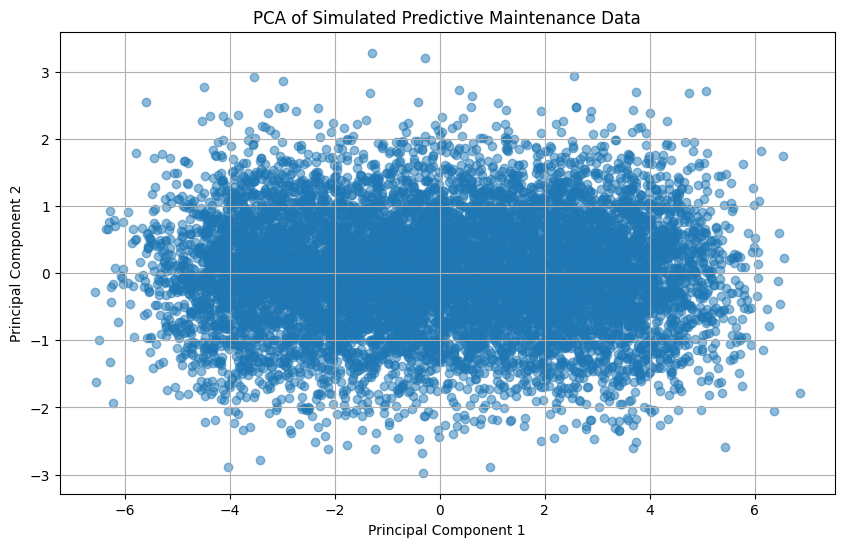

In [391]:
# Step 3: Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Step 4: Plot the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title("PCA of Simulated Predictive Maintenance Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

In [392]:
# Create a new point with 20 sensor values (matching your original data structure)
new_point = {}
for i in range(1, 21):
    # Simulate a sensor reading similar to your original data
    new_point[f'Sensor{i}'] = np.random.uniform(50, 100) + np.random.normal(0, 20)

# Convert to DataFrame with same column structure
new_point_df = pd.DataFrame([new_point])

print("New simulated point:")
print(new_point_df)

New simulated point:
    Sensor1    Sensor2    Sensor3    Sensor4     Sensor5     Sensor6  \
0  71.11035  77.718551  46.423748  84.290088  113.050647  102.042586   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  76.312061  83.300693  47.912127  75.908431  56.108257  84.615147   

    Sensor13    Sensor14   Sensor15   Sensor16  Sensor17  Sensor18   Sensor19  \
0  75.992426  107.482718  71.607757  97.585286  91.28264  77.46756  87.564371   

     Sensor20  
0  110.972088  


In [393]:
new_point_scaled = scaler.transform(new_point_df)
print("Scaled new simulated point:")
print(new_point_scaled)

new_point_transformed = pca.transform(new_point_scaled)
print("PCA-transformed new simulated point:")
print(new_point_transformed)

Scaled new simulated point:
[[-0.15635074  0.09869524 -1.15475621  0.38033439  1.54391734  1.08596516
   0.0444723   0.33488621 -1.10277944  0.04136508 -0.77343933  0.38474921
   0.04408106  1.30532238 -0.13788537  0.92479159  0.65850796  0.08979012
   0.52704141  1.45602126]]
PCA-transformed new simulated point:
[[ 1.24199703 -0.76560423]]


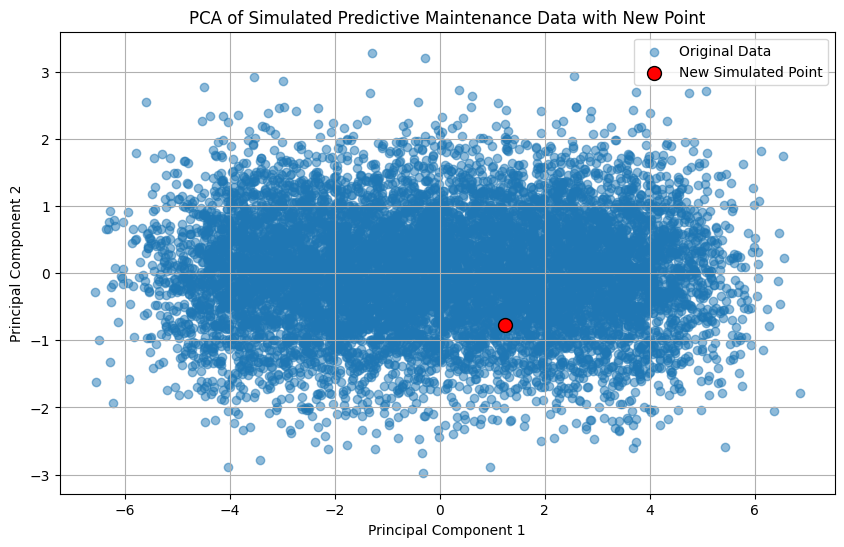

In [394]:
# Plot simulated point on PCA graph
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, label="Original Data")
plt.scatter(new_point_transformed[0, 0], new_point_transformed[0, 1], color='red', label="New Simulated Point", edgecolor='black', s=100)
plt.title("PCA of Simulated Predictive Maintenance Data with New Point")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

## 9.1-b

Do the following tasks:
1. Apply PCA with upto 5 components
2. Visualize how much variance of the dataset is defined by each component
3. Visualize the first 2 principal components and color them by timestep
4. Simulate a new position using code below
5. Plot the new point in the original 2D PCA graph

In [395]:
# Apply PCA with up to 5 components to see if we can capture more variance
pca_5 = PCA(n_components=5)
pca_5_result = pca_5.fit_transform(scaled_data)

# Print explained variance ratio for each component
print("Explained variance ratio for each component:")
for i, ratio in enumerate(pca_5.explained_variance_ratio_):
    print(f"Component {i+1}: {ratio:.4f}")

Explained variance ratio for each component:
Component 1: 0.3769
Component 2: 0.0359
Component 3: 0.0351
Component 4: 0.0349
Component 5: 0.0343


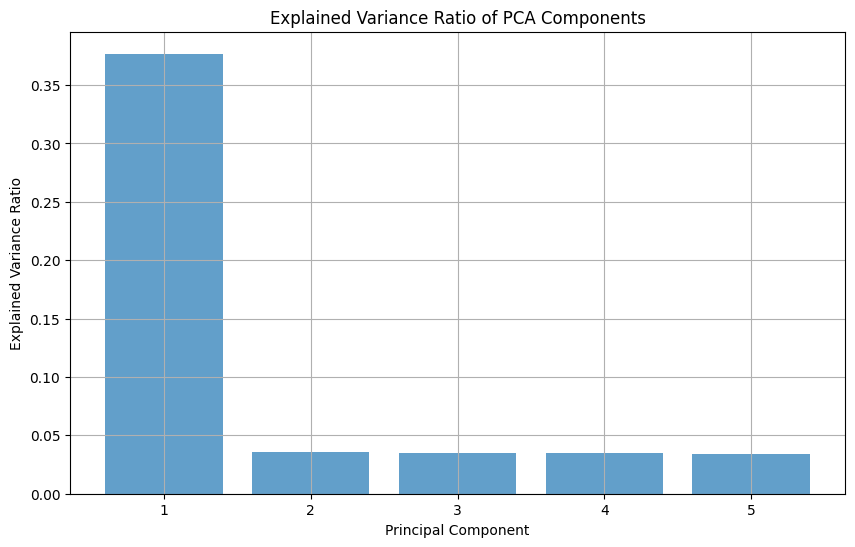

In [396]:
# Visualize how much varience of the dataset is defined by each component
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), pca_5.explained_variance_ratio_, alpha=0.7)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of PCA Components")
plt.grid()
plt.show()

## 9.2

Let us see how to setup an MQTT broker and send messages
Now, try yourself.

Use the diabetes.csv dataset to do the following:

1. Select the following 4 attributes (3 features + 1 class label):
    - Glucose
    - BloodPressure
    - Insulin
    - Outcome

2. Normalize Glucose, BloodPressure and Insulin to [0, 1] using MinMax.
3. Store the new data (3 normalized features + 1 class label) in another dataset S.
4. Modify the MQTT example to do the following:
    - The publisher publishes records in S continuously. When it reaches the end of S, it continues to send from the beginning again.
    - The subscriber continuously receives the data. For each latest record r received, apply the 3NN classification to the last 5 records before r, and compare the classification result with the Outcome label in r.
    - Repeat this for 1000 times, and report the number of correct classifications. 

In [397]:
diabetes = pd.read_csv("Data/diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [398]:
diabetes_isolated = diabetes[["Glucose", "BloodPressure","Insulin","Outcome"]]

diabetes_isolated.head()

,Glucose,BloodPressure,Insulin,Outcome
0,148,72,0,1
1,85,66,0,0
2,183,64,0,1
3,89,66,94,0
4,137,40,168,1


In [399]:
# Scaling to between 0 and 1
scaler = MinMaxScaler()
diabetes_scaled = pd.DataFrame(scaler.fit_transform(diabetes_isolated.drop("Outcome", axis=1)), columns=diabetes_isolated.columns[:-1])
diabetes_scaled["Outcome"] = diabetes_isolated["Outcome"]

diabetes_scaled.head()

,Glucose,BloodPressure,Insulin,Outcome
0,0.743719,0.590164,0.000000,1
1,0.427136,0.540984,0.000000,0
2,0.919598,0.524590,0.000000,1
3,0.447236,0.540984,0.111111,0
4,0.688442,0.327869,0.198582,1


In [400]:
# OnConnect function

def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("Connected to MQTT Broker!")
    else:
        print("Failed to connect, return code %d\n", rc)
    
# Setup mttq publisher
mqtt_client = mqtt.Client()
mqtt_client.connect("broker.hivemq.com", 1883, 60) # Connecting to the broker, needs an active site





/tmp/ipykernel_6699/2464479972.py:10: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client()


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>

# Exercise 10

## 10.1

In this exercise, we will use a bike sharing dataset. The dataset contains coordinates of bike sharing stations in New York given as longitude and latitude values.

The dataset is an example dataset from the book ["Introduction to R for Business Intelligence"](https://jgendron.github.io/com.packtpub.intro.r.bi/), Packt Publishing Ltd., 2016, by Jay Gendron. The dataset is downloadable from Github [here](https://github.com/jgendron/com.packtpub.intro.r.bi/tree/master/Chapter5-ClusteringAnalysis/data), but is also available on Moodle as "Ch5_bike_station_locations.csv".

Answer the following questions:
1. Apply K-Means clustering to the dataset. Try out different values for K and use the Elbow method to find the best (or a sensible) K.
2. Visualize the K-Means clustering result for the best K.
3. Apply Agglomerative clustering to the dataset. Draw the Dendrogram and use it to find the best (or a sensible) number of clusters.
4. Generate this number of clusters with Agglomerative clustering and visualize the clustering.
5. Apply DBSCAN clustering to the dataset. Try out different values for "eps" and "min_samples" and choose the best values. (Hint: For "eps" you probably have to try out values around 0.01.)
6. Visualize the final DBSCAN clustering you decided upon in 5.
7. Calculate the Silhouette scores for the three different "best clustering" you found with the three different methods. Also use Adjusted Rand Index to compare the best ones to each other.


In [401]:
bikes = pd.read_csv("Data/Ch5_bike_station_locations.csv")
bikes.head()

,latitude,longitude
0,38.956590,-76.993437
1,38.905218,-77.001496
2,38.980858,-77.054722
3,38.902925,-76.929915
4,38.949498,-77.093620


In [68]:
print(bikes.info())
print(bikes.describe())

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   244 non-null    float64
 1   longitude  244 non-null    float64
dtypes: float64(2)
memory usage: 3.9 KB
None
         latitude   longitude
count  244.000000  244.000000
mean    38.914289  -77.010109
std      0.035435    0.041084
min     38.827425  -77.106502
25%     38.891574  -77.031987
50%     38.916397  -77.011474
75%     38.935887  -76.985866
max     38.987980  -76.919470


In [69]:
# Scale the data before clustering
from sklearn.preprocessing import StandardScaler

X = bikes[["latitude", "longitude"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [70]:
# Fit K-means on scaled data
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [71]:
kmeans.labels_

array([1, 0, 2, 0, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 2, 2, 1, 2, 0, 0, 1,
       1, 0, 2, 1, 2, 1, 1, 0, 0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 0, 1, 2, 1,
       0, 1, 0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 2, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 2, 0, 0, 1, 2, 0, 1, 2, 1, 0, 2, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 0, 1, 2, 0, 1, 1, 0, 1, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1,
       2, 2, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 2, 1, 0, 1,
       1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 1, 0, 1, 1, 1, 0, 2, 1,
       0, 1, 1, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1,
       1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 1, 1, 1, 0, 0, 1, 1, 0, 2, 1, 0, 1,
       1, 2, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 0, 0, 2, 0, 2, 0, 1,
       0, 1], dtype=int32)

In [72]:
kmeans.cluster_centers_

array([[-0.98102087,  0.82726744],
       [ 0.6955807 , -0.03317816],
       [ 0.50907102, -1.34830068]])

In [73]:
# Check the cluster labels
print("Cluster labels:", kmeans.labels_)
print("Number of points in each cluster:", np.bincount(kmeans.labels_))

Cluster labels: [1 0 2 0 2 2 0 0 0 0 2 0 0 0 1 2 2 1 2 0 0 1 1 0 2 1 2 1 1 0 0 0 1 2 1 2 1
 0 1 1 0 1 2 1 0 1 0 2 0 2 0 1 0 0 0 0 0 0 1 0 2 2 2 1 0 0 0 1 1 1 1 1 1 1
 0 1 1 1 0 2 0 2 2 2 1 2 0 1 0 0 1 0 2 0 0 1 2 0 1 2 1 0 2 2 1 1 2 1 1 1 1
 1 0 1 2 0 1 1 0 1 0 1 2 2 2 0 0 0 0 0 1 1 2 2 1 0 0 0 2 1 1 1 1 2 1 2 2 1
 1 0 2 1 0 1 1 0 2 0 1 1 0 0 0 0 1 0 2 2 1 0 1 1 1 0 2 1 0 1 1 2 0 0 0 2 0
 0 0 2 0 1 0 0 2 1 0 0 0 1 1 1 2 1 2 2 1 0 0 2 1 1 1 0 0 1 1 0 2 1 0 1 1 2
 1 0 1 0 0 1 0 0 1 1 1 2 0 0 0 2 0 2 0 1 0 1]
Number of points in each cluster: [95 93 56]


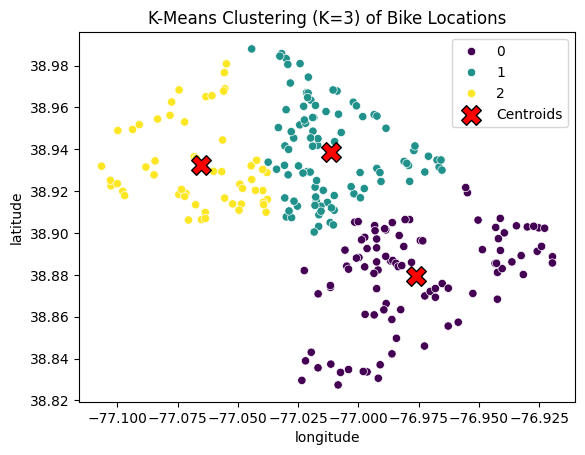

In [74]:
# Visualize the clustering
bikes["3MeansCluster"] = kmeans.labels_

# Transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="3MeansCluster", palette="viridis")
# Note: cluster_centers_original[:,0] is latitude, [:,1] is longitude
plt.scatter(x=cluster_centers_original[:,1], y=cluster_centers_original[:,0], 
            color='red', s=200, marker='X', edgecolor='black', label='Centroids')
plt.title("K-Means Clustering (K=3) of Bike Locations")
plt.legend()
plt.show()

# Exercise 11

## 11.1

In this exercise, we will learn how to evaluate classification models using various metrics.

Using the diabetes dataset, do the following:
1. Load the diabetes dataset
2. Select features (drop "Age" and "Outcome") as X and "Outcome" as y
3. Do a train-test split with 25% for testing (use random_state=42)
4. Train two KNN models with K=5 and K=10
5. Create confusion matrices for both models (both as arrays and as visualizations using ConfusionMatrixDisplay)
6. Calculate accuracy, precision, recall, and F1-score for both models
7. Create a DataFrame to compare the evaluation metrics
8. Visualize the normalized confusion matrix (with percentages)
9. Plot ROC curves for both models
10. Calculate and compare the AUC (Area Under Curve) for both models
11. Which model performs better and why?

# Exercise 12

## 12.1

In this exercise, we will work with Decision Trees and Ensemble Models.

Using the diabetes dataset, complete the following tasks:
1. Load the diabetes dataset
2. Select "Glucose", "BloodPressure", "Insulin", and "BMI" as features (X) and "Outcome" as target (y)
3. Do a train-test split with 20% for testing (use random_state=8532)
4. Train a basic Decision Tree classifier
5. Make predictions on both training and test sets
6. Create confusion matrices for both training and test predictions
7. Calculate accuracy, precision, recall, and F1-score for both sets
8. Visualize the decision tree structure (optional: requires graphviz)
9. Train a Random Forest classifier and evaluate it
10. Train an AdaBoost classifier and evaluate it
11. Train an XGBoost classifier and evaluate it
12. Compare all four models - which performs best?
13. Try to reduce overfitting in the decision tree by tuning max_depth parameter

# Exercise 13

## 13.1

- Install required packages (networkx, pandas, numpy, matplotlib).
- Define nodes and directed edges; build a `DiGraph` and list nodes/edges.
- Visualize the directed graph.
- Compute in-degree/out-degree and answer the degree questions.
- Implement `is_walk`, `is_trail`, `is_path` and run the self-checks.
- Compute strong/weak components and answer the component questions.
- Build the adjacency matrix and answer row/column interpretation questions.
- Compute $A^2$ and $A^3$ and interpret length-2 and length-3 walk counts.
- Build an adjacency matrix from the edge list without NetworkX and compare with `A`.
- Save edge list and adjacency matrix to CSV.

In [402]:
import networkx as nx

ModuleNotFoundError: No module named 'networkx'

## 13.2

- Verify the required file df_climate_obstruction.csv is present.
- Run setup imports and set plotting defaults.
- Load the CSV, keep required columns, clean text fields, and drop missing actor/domain rows.
- Build a directed actor→domain edge list with weights and save it.
- Build a directed graph from that edge list and report node/edge counts.
- Create the actor×domain adjacency (incidence) matrix.
- Compute the actor–actor shared-domain matrix using $B B^\top$.
- Build an undirected actor–actor edge list from shared domains, save it, and build the actor graph.
- Compute centrality measures and communities; summarize top actors and export metrics.
- Attach node attributes and export directed/undirected graphs to GEXF for Gephi.
- Answer the interpretation questions on centrality, projection meaning, edge list vs matrix, and weighted edges.

In [403]:
# data = pd.read_csv("Data/df_climate_obstruction.csv")

# data.head()

In [404]:
import networkx as nx

In [405]:
# data.dropna(inplace=True)



## 13.3

- Confirm the dataset file df_climate_obstruction_german_notext.csv exists.
- Compare Pandas vs Polars on a small sample (filter/select/preview).
- Read data lazily with `scan_csv`, inspect schema, and review the query plan with `.explain()`.
- Preview key columns and collect a small sample.
- Filter rows where `co_pred == 1` and `domain_clean` is not null.
- Group and list top domains and top actors.
- Create a `high_conf` indicator and summarize its share by platform.
- Join top actors with their most common `account_type`.
- Convert between Polars and Pandas as needed.
- Export the top domains result to CSV and answer the reflection questions.

# Exercise 14

## 14.1

- Train at least two basic models on the energy dataset from TSA_Example notebook. You may choose to use only the last 5 years of the dataset to reduce data size
- Explain the patterns the model has learned via various plotting capabilities

In [406]:
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,hum,windspeed,casual,registered,cnt,datetime_obj,Day,Week,Month,Year
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.81,0.0,3,13,16,2011-01-01,0,5,1,2011
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.80,0.0,8,32,40,2011-01-01,0,5,1,2011
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.80,0.0,5,27,32,2011-01-01,0,5,1,2011
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.75,0.0,3,10,13,2011-01-01,0,5,1,2011
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.75,0.0,0,1,1,2011-01-01,0,5,1,2011


In [407]:
X = hour.drop(columns=["cnt", "dteday", "datetime_obj"])
Y = hour["cnt"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [408]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

intercept = lin_reg.intercept_
coefficients = lin_reg.coef_
equation = "Quality = {:.2f}".format(intercept)
for feature, coef in zip(X.columns, coefficients):
    equation += " + ({:.2f} * {})".format(coef, feature)
print("Linear Regression Equation:")
print(equation)

Linear Regression Equation:
Quality = -0.00 + (0.00 * instant) + (-0.00 * season) + (0.00 * yr) + (0.00 * mnth) + (-0.00 * hr) + (0.00 * holiday) + (-0.00 * weekday) + (0.00 * workingday) + (0.00 * weathersit) + (-0.00 * temp) + (-0.00 * atemp) + (-0.00 * hum) + (0.00 * windspeed) + (1.00 * casual) + (1.00 * registered) + (0.00 * Day) + (-0.00 * Week) + (0.00 * Month) + (0.00 * Year)


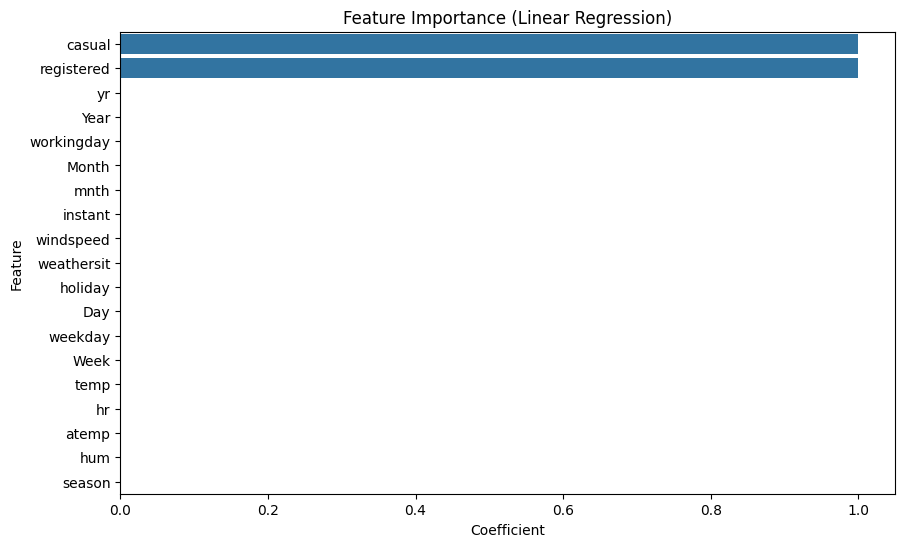

In [409]:
# Feature importance via correlation
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg.coef_})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Linear Regression)')
plt.show()

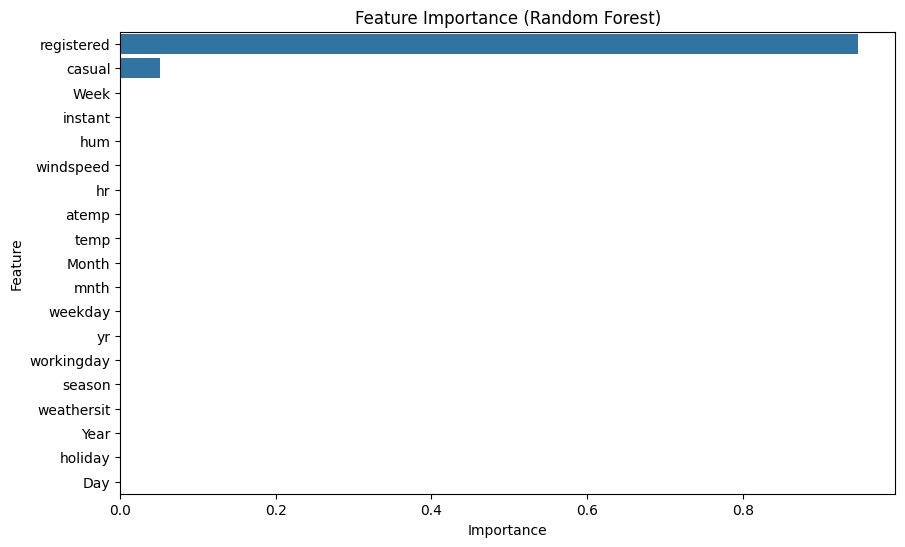


Partial Dependence Plot (PDP) helps us understand the relationship between a specific feature and the predicted target while keeping other features constant. It shows how the model's prediction changes as the feature's value varies.


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


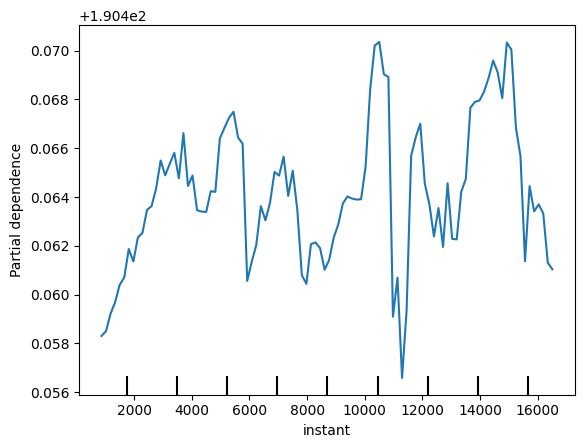

In [410]:
# Train a more complex model (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Feature importance for complex model
importances = rf.feature_importances_
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Plot feature importance (Random Forest)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('Feature Importance (Random Forest)')
plt.show()

# Partial Dependence Plot for a single feature
print("\nPartial Dependence Plot (PDP) helps us understand the relationship between a specific feature and the predicted target while keeping other features constant. It shows how the model's prediction changes as the feature's value varies.")
feature_idx = 0  # Change this to visualize different features
PartialDependenceDisplay.from_estimator(rf, X_train, [feature_idx])
plt.show()

## 14.2

- Train at least two advanced models on the energy dataset from TSA_Example notebook. You may choose to use only the last 5 years of the dataset to reduce data size
- Explain the patterns the model has learned using SHAP local and global plots
- Explain the patterns using LIME
- Compare the answers from LIME & SHAP (global & some local) – what do you see? Is it the same?

# Exercise 15

## 15.1

Try out the "Further experiments" mentioned at the end of the binary classification of IMDB movie review model ([Classifying movie reviews: A binary classification example](https://deeplearningwithpython.io/chapters/chapter04_classification-and-regression/#classifying-movie-reviews-a-binary-classification-example)) of chapter 4 of the book. (You can use the code from the chapter 4 notebook "chapter04_classification-and-regression.ipynb" as your departure.)

## 15.2

Try out the "Further experiments" mentioned at the end of the multiclass classification example of classifying newswires ([Classifying newswires: A multiclass classification example](https://deeplearningwithpython.io/chapters/chapter04_classification-and-regression/#classifying-newswires-a-multiclass-classification-example)) of chapter 4 of the book. (You can use the code from the chapter 4 notebook "chapter04_classification-and-regression.ipynb" as your departure.)

# Exercise 16

## 16.1

1. Now create embeddings using TFIDF & Transformer model as used in example notebook
2. Try some other transformer models from HuggingFace to do embedding - 'microsoft/deberta-v3-large' or 'roberta-large-mnli'
2. Train and evaluate models with each embedding separately
3. Train a model with all embeddings and evaluate
4. Which one is performing the best, why do you think it is the best?

## 16.2

1. Creat a RAG pipeline that can take following text and answer following questions
2. Try different types of chunking to get better answers?
3. Does asking questions differently give better answers? Why?
4. Try a different similarity search instead of cosine similarity - do the answers improve?

# Exercise 17

## 17.1

In this exercise, we will explore hyper-parameter tuning and cross-validation techniques.

Using the diabetes dataset, complete the following tasks:
1. Load the diabetes dataset
2. Select features (drop "Age" and "Outcome") as X and "Outcome" as y
3. Train 50 different KNN models with K=5 using different random train-test splits
4. Create a histogram showing the distribution of test accuracies across different splits
5. For each of the 50 train-test splits, find the best K value (between 2 and 30)
6. Create a histogram showing the distribution of best K values
7. Implement Grid Search with cross-validation to find the best K for KNN
8. Implement Random Search with cross-validation for hyperparameter tuning
9. Use cross_val_score to evaluate model performance with 5-fold cross-validation
10. Compare the results from different tuning methods
11. Apply Grid Search to tune hyperparameters for a Random Forest model
12. Which method gives you the most reliable results and why?